In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob

In [2]:
from google.colab import files

uploaded = files.upload()

Saving comments.csv to comments (1).csv


In [3]:
df = pd.read_csv("comments.csv")

df.head()

,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count
0,1,unde at dolorem,2,1,13-04-2023 08:04,April 14,yes,1
1,2,quae ea ducimus,3,1,13-04-2023 08:04,April 14,no,2
2,3,alias a voluptatum,5,1,13-04-2023 08:04,April 14,no,4
3,4,facere suscipit sunt,14,1,13-04-2023 08:04,April 14,yes,2
4,5,totam eligendi quaerat,17,1,13-04-2023 08:04,April 14,yes,1


In [5]:
print("Dataset Shape:", df.shape)

df.info()

df.describe(include='all')

Dataset Shape: (7488, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7488 entries, 0 to 7487
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   7488 non-null   int64 
 1   comment              7488 non-null   object
 2   User  id             7488 non-null   int64 
 3   Photo id             7488 non-null   int64 
 4   created Timestamp    7488 non-null   object
 5   posted date          7488 non-null   object
 6   emoji used           7488 non-null   object
 7   Hashtags used count  7488 non-null   int64 
dtypes: int64(4), object(4)
memory usage: 468.1+ KB


,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count
count,7488.000000,7488,7488.000000,7488.000000,7488,7488,7488,7488.000000
unique,NaN,7467,NaN,NaN,1,1,2,NaN
top,NaN,et et et,NaN,NaN,13-04-2023 08:04,April 14,yes,NaN
freq,NaN,3,NaN,NaN,7488,7488,3744,NaN
mean,3744.500000,NaN,48.949386,129.099225,NaN,NaN,NaN,2.416667
std,2161.743741,NaN,28.354045,73.776439,NaN,NaN,NaN,1.705905
min,1.000000,NaN,2.000000,1.000000,NaN,NaN,NaN,0.000000
25%,1872.750000,NaN,24.000000,65.000000,NaN,NaN,NaN,1.000000
50%,3744.500000,NaN,48.000000,130.000000,NaN,NaN,NaN,2.000000
75%,5616.250000,NaN,72.000000,193.000000,NaN,NaN,NaN,3.250000


In [6]:
df.describe(include='all')

,id,comment,User id,Photo id,created Timestamp,posted date,emoji used,Hashtags used count
count,7488.000000,7488,7488.000000,7488.000000,7488,7488,7488,7488.000000
unique,NaN,7467,NaN,NaN,1,1,2,NaN
top,NaN,et et et,NaN,NaN,13-04-2023 08:04,April 14,yes,NaN
freq,NaN,3,NaN,NaN,7488,7488,3744,NaN
mean,3744.500000,NaN,48.949386,129.099225,NaN,NaN,NaN,2.416667
std,2161.743741,NaN,28.354045,73.776439,NaN,NaN,NaN,1.705905
min,1.000000,NaN,2.000000,1.000000,NaN,NaN,NaN,0.000000
25%,1872.750000,NaN,24.000000,65.000000,NaN,NaN,NaN,1.000000
50%,3744.500000,NaN,48.000000,130.000000,NaN,NaN,NaN,2.000000
75%,5616.250000,NaN,72.000000,193.000000,NaN,NaN,NaN,3.250000


In [7]:
df.isnull().sum()

,0
id,0
comment,0
User id,0
Photo id,0
created Timestamp,0
posted date,0
emoji used,0
Hashtags used count,0


In [8]:
df = df.drop_duplicates()

print(df.shape)

(7488, 8)


In [9]:
df['created Timestamp'] = pd.to_datetime(df['created Timestamp'])

/tmp/ipykernel_2529/262794593.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['created Timestamp'] = pd.to_datetime(df['created Timestamp'])


In [10]:
df['Year'] = df['created Timestamp'].dt.year
df['Month'] = df['created Timestamp'].dt.month
df['Day'] = df['created Timestamp'].dt.day
df['Hour'] = df['created Timestamp'].dt.hour
df['Weekday'] = df['created Timestamp'].dt.day_name()

In [11]:
df[['Year','Month','Day','Hour','Weekday']].head()

,Year,Month,Day,Hour,Weekday
0,2023,4,13,8,Thursday
1,2023,4,13,8,Thursday
2,2023,4,13,8,Thursday
3,2023,4,13,8,Thursday
4,2023,4,13,8,Thursday


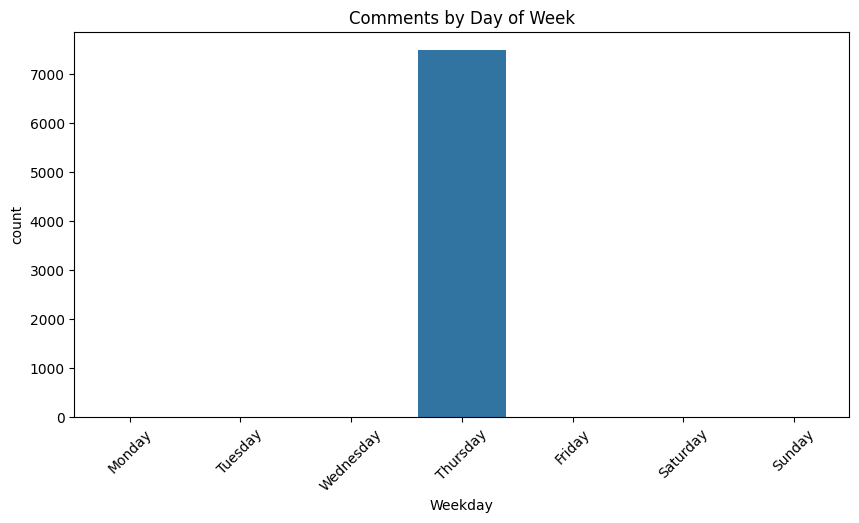

In [12]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Weekday',
    data=df,
    order=['Monday',
           'Tuesday',
           'Wednesday',
           'Thursday',
           'Friday',
           'Saturday',
           'Sunday']
)

plt.title('Comments by Day of Week')
plt.xticks(rotation=45)
plt.show()

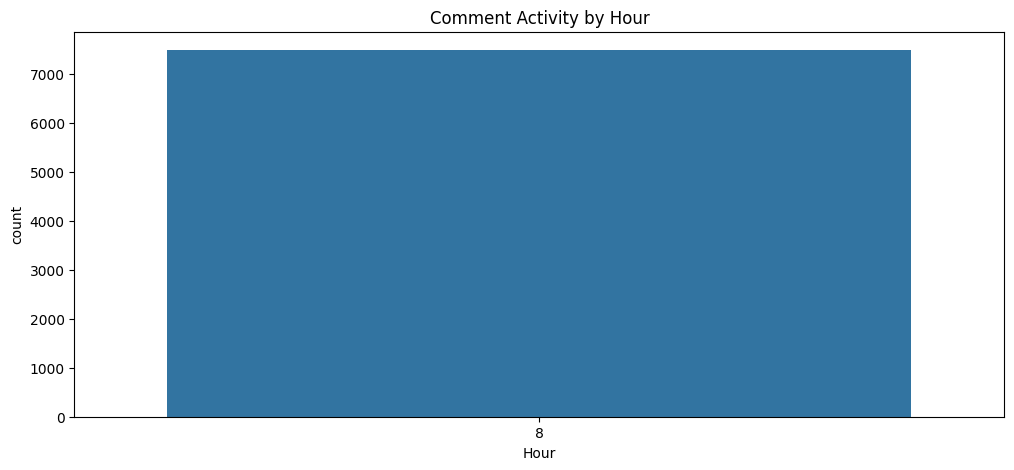

In [13]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='Hour',
    data=df
)

plt.title('Comment Activity by Hour')
plt.show()

top_posts = df['Photo id'].value_counts().head(10)

print(top_posts)

In [16]:
top_users = df['User  id'].value_counts().head(10)

print(top_users)

User  id
5     257
14    257
36    257
24    257
21    257
54    257
41    257
91    257
76    257
71    257
Name: count, dtype: int64


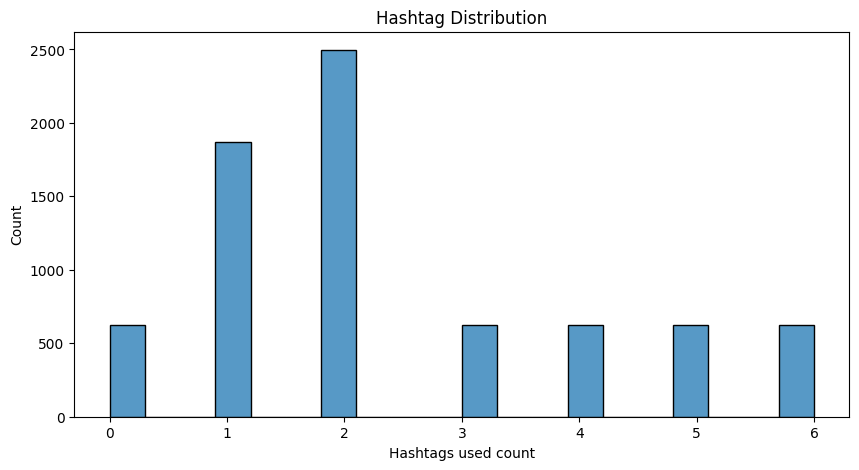

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Hashtags used count'],
    bins=20
)

plt.title('Hashtag Distribution')

plt.show()

avg_hashtags = df['Hashtags used count'].mean()

print(avg_hashtags)

In [19]:
df['Comment_Length'] = df['comment'].astype(str).apply(len)

In [20]:
df[['comment','Comment_Length']].head()

,comment,Comment_Length
0,unde at dolorem,15
1,quae ea ducimus,15
2,alias a voluptatum,18
3,facere suscipit sunt,20
4,totam eligendi quaerat,22


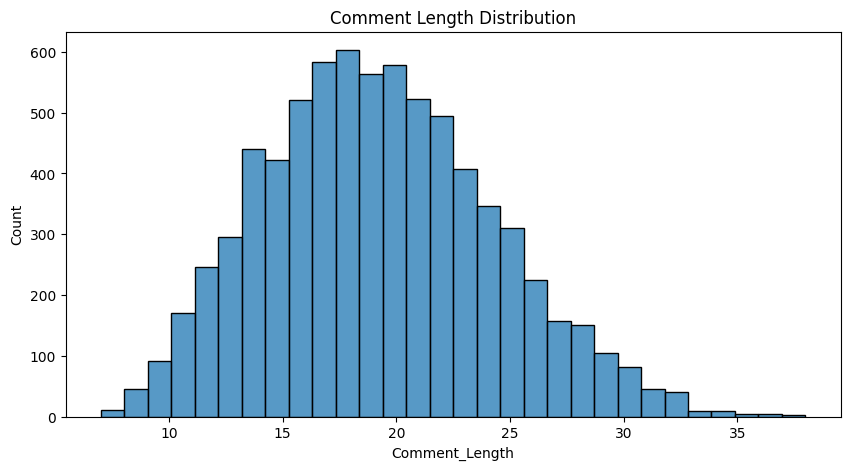

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Comment_Length'],
    bins=30
)

plt.title('Comment Length Distribution')

plt.show()

In [22]:
from textblob import TextBlob

def get_sentiment(text):

    try:

        score = TextBlob(str(text)).sentiment.polarity

        if score > 0:
            return "Positive"

        elif score < 0:
            return "Negative"

        else:
            return "Neutral"

    except:
        return "Neutral"

In [24]:
df['Sentiment'] = df['comment'].apply(get_sentiment)

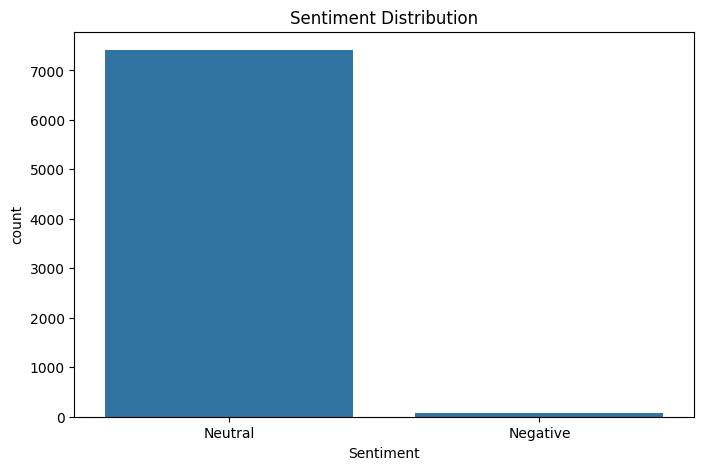

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Sentiment',
    data=df
)

plt.title('Sentiment Distribution')

plt.show()

In [26]:
monthly_comments = df.groupby('Month').size()

plt.figure(figsize=(10,5))

monthly_comments.plot(
    marker='o'
)

plt.title('Monthly Comment Activity')

plt.ylabel('Comments')

plt.show()

In [29]:
print("Total Comments:", len(df))

print("Unique Users:",
      df['User  id'].nunique())

print("Unique Posts:",
      df['Photo id'].nunique())

print("Average Comment Length:",
      round(df['Comment_Length'].mean(),2))

Total Comments: 7488
Unique Users: 77
Unique Posts: 257
Average Comment Length: 19.34
